# **IPA Canonical Pathways**

✅ Saved: IPA_CanonicalPathways_Compact_RightAlign_300dpi.png


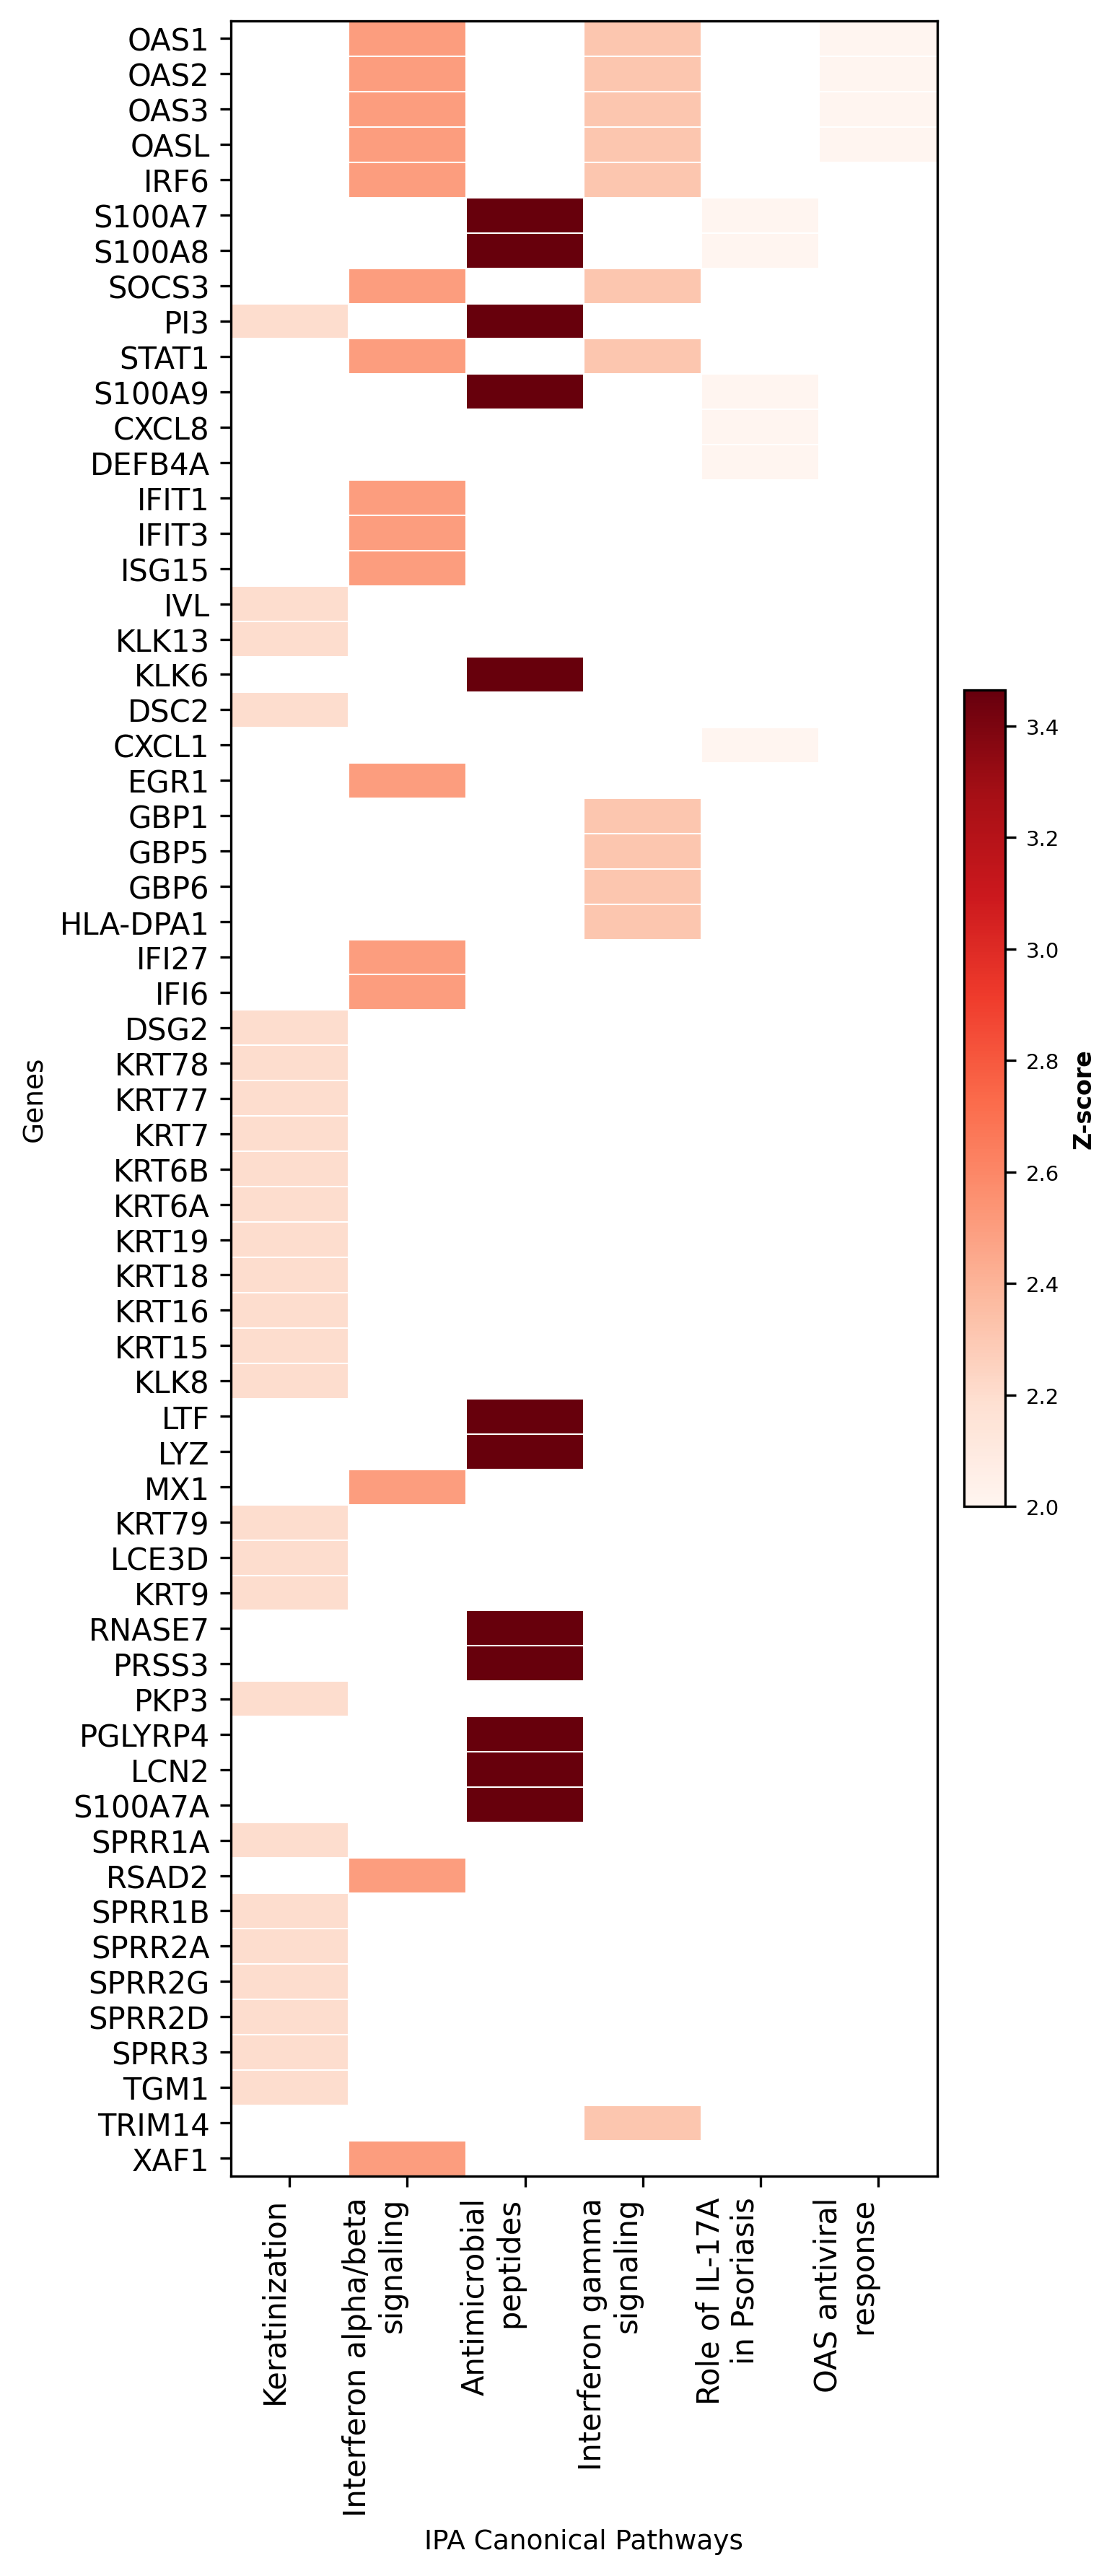

In [ ]:
# -*- coding: utf-8 -*-
# Compact Heatmap: Genes × IPA Canonical Pathways
# - Pathway names on 2 lines, right-aligned
# - Reduced height and width
# - Bold ticks/labels, 300 DPI

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Input data (Canonical Pathways with z-scores)
# -----------------------------
rows = [
    {"Pathway": "Antimicrobial\npeptides", "zscore": 3.464,
     "Molecules": "KLK6,LCN2,LTF,LYZ,PGLYRP4,PI3,PRSS3,RNASE7,S100A7,S100A7A,S100A8,S100A9"},
    {"Pathway": "Interferon alpha/beta\nsignaling", "zscore": 2.5,
     "Molecules": "EGR1,IFI27,IFI6,IFIT1,IFIT3,IRF6,ISG15,MX1,OAS1,OAS2,OAS3,OASL,RSAD2,SOCS3,STAT1,XAF1"},
    {"Pathway": "Interferon gamma\nsignaling", "zscore": 2.309,
     "Molecules": "GBP1,GBP5,GBP6,HLA-DPA1,IRF6,OAS1,OAS2,OAS3,OASL,SOCS3,STAT1,TRIM14"},
    {"Pathway": "Keratinization", "zscore": 2.2,
     "Molecules": "DSC2,DSG2,IVL,KLK13,KLK8,KRT15,KRT16,KRT18,KRT19,KRT6A,KRT6B,KRT7,KRT77,KRT78,KRT79,KRT9,"
                  "LCE3D,PI3,PKP3,SPRR1A,SPRR1B,SPRR2A,SPRR2D,SPRR2G,SPRR3,TGM1"},
    {"Pathway": "OAS antiviral\nresponse", "zscore": 2.0,
     "Molecules": "OAS1,OAS2,OAS3,OASL"},
    {"Pathway": "Role of IL-17A\nin Psoriasis", "zscore": 2.0,
     "Molecules": "CXCL1,CXCL8,DEFB4A,S100A7,S100A8,S100A9"}
]
df = pd.DataFrame(rows)

# -----------------------------
# 2) Expand gene lists
# -----------------------------
df_long = (
    df.assign(Gene=df["Molecules"].str.split(","))
      .explode("Gene")
      .drop(columns=["Molecules"])
)
df_long["Gene"] = df_long["Gene"].str.strip()

# -----------------------------
# 3) Build z-score matrix
# -----------------------------
mat = df_long.pivot_table(index="Gene", columns="Pathway", values="zscore", aggfunc="max")

# -----------------------------
# 4) Order for readability
# -----------------------------
presence = (~mat.isna()).astype(int)
pathway_order = presence.sum(axis=0).sort_values(ascending=False).index
gene_order = presence.sum(axis=1).sort_values(ascending=False).index
mat = mat.loc[gene_order, pathway_order]

# -----------------------------
# 5) Plot heatmap
# -----------------------------
n_rows, n_cols = mat.shape
fig, ax = plt.subplots(figsize=(7, 12), dpi=300)  # Adjusted width & height for larger labels

data = mat.to_numpy(dtype=float)
mask = np.isnan(data)
masked_data = np.ma.masked_array(data, mask=mask)

im = ax.imshow(masked_data, aspect=0.3, interpolation="nearest", cmap="Reds") # Reduced box width
im.set_clim(np.nanmin(data), np.nanmax(data))

# Background
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# Axis ticks and labels
ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))
ax.set_xticklabels(mat.columns, rotation=90, fontsize=10, ha='right')  # Increased fontsize
ax.set_yticklabels(mat.index, fontsize=10) # Increased fontsize

ax.set_xlabel("IPA Canonical Pathways", fontsize=9)
ax.set_ylabel("Genes", fontsize=9)

# Grid
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Z-score", fontweight="bold", fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()

# -----------------------------
# 6) Save 300 DPI output
# -----------------------------
out_png = "IPA_CanonicalPathways_Compact_RightAlign_300dpi.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
print(f"✅ Saved: {out_png}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib import cm
import matplotlib.patches as mpatches

# -----------------------------
# 5) Plot heatmap (Publication-ready)
# -----------------------------
n_rows, n_cols = mat.shape

# --- Dynamic figure sizing ---
# Give each row at least 0.55 inches and each col ~0.20 inches
fig_height = max(5, n_rows * 0.55 + 2.5)
fig_width  = max(14, n_cols * 0.20 + 4.5)

fig = plt.figure(figsize=(fig_width, fig_height), dpi=300)
fig.patch.set_facecolor("white")

# Use GridSpec: main axes + narrow colorbar axes side by side
# The colorbar column is fixed-width via width_ratios
gs = gridspec.GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[1, 0.025],   # heatmap takes almost all width
    wspace=0.04                # tight gap between heatmap and cbar
)
ax  = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])   # dedicated colorbar axes → always parallel

ax.set_facecolor("white")

# --- Data ---
data        = mat.to_numpy(dtype=float)
mask        = np.isnan(data)
masked_data = np.ma.masked_array(data, mask=mask)

vmin = np.nanmin(data)
vmax = np.nanmax(data)

im = ax.imshow(
    masked_data,
    aspect="auto",            # fills the axes cleanly
    interpolation="nearest",
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)

# --- Colorbar (explicitly in its own axes → stays parallel) ---
norm = Normalize(vmin=vmin, vmax=vmax)
sm   = cm.ScalarMappable(cmap="Reds", norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(
    "Z-score",
    fontsize=13,
    labelpad=10
)
cbar.ax.tick_params(labelsize=11)
cbar.ax.yaxis.set_tick_params(length=3)

# --- X-axis ticks (genes) ---
ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(
    mat.columns,
    rotation=90,
    fontsize=11,
    ha="center",
    va="top"
)
ax.tick_params(axis="x", length=3, pad=3)

# --- Y-axis ticks (pathways) ---
# Dynamically scale font so labels never overlap:
#   base 12pt, shrink to min 7pt as row count grows
y_fontsize = max(7, min(12, int(130 / max(n_rows, 1))))

ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(
    mat.index,
    fontsize=y_fontsize,
    va="center"
)
ax.tick_params(axis="y", length=0, pad=6)   # no tick marks on y

# Push y-labels far enough left that long names don't crowd the heatmap
ax.yaxis.set_tick_params(pad=8)

# --- Axis labels ---
ax.set_xlabel(
    "Genes",
    fontsize=16,
    labelpad=12
)
ax.set_ylabel(
    "IPA Canonical Pathways",
    fontsize=16,
    labelpad=14
)

# --- Cell grid (white lines between cells) ---
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

# --- Spine cleanup (keep only bottom + left) ---
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# --- Tight layout with explicit padding ---
plt.tight_layout(rect=[0, 0, 1, 1], pad=1.5)

# --- Save ---
out_png = "IPA_CanonicalPathways_PublicationReady_300dpi.png"
plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
print(f"Saved: {out_png}")
plt.show()

Saved: IPA_CanonicalPathways_PublicationReady_300dpi.png


## **ML Disease Pathways**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Input data
# =====================================================
data = [
    ("Allergic inflammation", 3.70, 0.143, 6, 2, "CHRM3, IL6"),
    ("Early-onset myopathy", 2.17, 0.108, 4, 1, "FASN"),
    ("Familial insulin resistance", 4.41, 0.152, 7, 4, "FASN, PCK1, PPARG, PPARGC1A"),
    ("Hyperglycemia", 2.58, 0.106, 5, 2, "PCK1, PPARG"),
    ("Hyperglyceridemia", 2.88, 0.167, 4, 2, "LPL, PPARG"),
    ("Hypertriglyceridemia", 2.88, 0.167, 4, 2, "LPL, PPARG"),
    ("Insulin resistance", 6.24, 0.184, 9, 1, "PPARG"),
    ("Metabolic syndrome X", 3.23, 0.118, 6, 1, "PPARG"),
    ("Neuroinflammation", 3.59, 0.136, 6, 2, "IL6, PTGS2"),
    ("Occlusion of artery", 2.84, 0.122, 5, 1, "PTGS2"),
    ("Occlusion of blood vessel", 3.70, 0.143, 6, 2, "PTGS2, VEGFA"),
    ("Oxidative stress", 4.23, 0.176, 6, 3, "PPARG, PPARGC1A, SOD2"),
    ("Psoriasis", 2.05, 0.100, 4, 1, "CXCL8"),
]

df = pd.DataFrame(
    data,
    columns=[
        "ML Disease Pathway",
        "-log(p-value)",
        "Ratio",
        "Molecules Count",
        "No. of GoI Present",
        "Genes"
    ]
)

# =====================================================
# Sort
# =====================================================
df = df.sort_values(
    by=["No. of GoI Present", "-log(p-value)"],
    ascending=[False, False]
).reset_index(drop=True)

# =====================================================
# Figure setup
# =====================================================
fig, ax = plt.subplots(figsize=(14, 9))

y = np.arange(len(df))

# =====================================================
# Plot bars
# =====================================================
blue = "#0066CC"
orange = "#FF7A00"

# Background bars
bars1 = ax.barh(
    y,
    df["Molecules Count"],
    color=blue,
    height=0.72,
    label="Total molecules in IPA category",
    zorder=1
)

# Foreground bars
bars2 = ax.barh(
    y,
    df["No. of GoI Present"],
    color=orange,
    height=0.72,
    label="Phytochemical gene targets",
    zorder=2
)

# =====================================================
# Gene labels inside orange bars
# =====================================================
for i, (goi, genes) in enumerate(
    zip(df["No. of GoI Present"], df["Genes"])
):

    if goi > 0:

        # Larger publication-ready font sizes
        fs = 15

        if len(genes) > 28:
            fs = 13

        if len(genes) > 40:
            fs = 11

        ax.text(
            x=goi / 2,
            y=i,
            s=genes,
            ha='center',
            va='center',
            color='white',
            fontsize=fs,
            zorder=3
        )

# =====================================================
# Molecule count labels at end of blue bars
# =====================================================
for i, val in enumerate(df["Molecules Count"]):

    ax.text(
        val + 0.1,
        i,
        str(val),
        va='center',
        fontsize=16,
        color='black'
    )

# =====================================================
# Axis labels
# =====================================================
ax.set_xlabel(
    "Count",
    fontsize=20,
    labelpad=10
)

ax.set_ylabel(
    "ML Disease Pathways",
    fontsize=20,
    labelpad=10
)

# =====================================================
# Tick labels
# =====================================================
ax.set_yticks(y)

ax.set_yticklabels(
    df["ML Disease Pathway"],
    fontsize=18
)

ax.tick_params(
    axis='x',
    labelsize=20,
    width=2,
    length=7
)

# =====================================================
# Axis styling
# =====================================================
ax.invert_yaxis()

# Thick left/bottom spines
ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)

# Remove top/right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# =====================================================
# Limits
# =====================================================
ax.set_xlim(0, max(df["Molecules Count"]) + 1)

# =====================================================
# Legend (bottom right)
# =====================================================
legend = ax.legend(
    loc='lower right',
    fontsize=16,
    frameon=True,
    borderpad=0.8,
    handlelength=1.6,
    handleheight=1.6,
    labelspacing=1
)

legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linestyle('--')

# =====================================================
# Final layout
# =====================================================
plt.tight_layout()

# =====================================================
# Save publication-ready figure
# =====================================================
plt.savefig(
    "ML_Disease_Pathways_Publication_Ready_300DPI.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## **Diseases & Biofunctions**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Input data
# ===============================
data = [
    ("Activation of blood cells", 84, 21),
    ("Activation of cells", 110, 26),
    ("Activation of leukocytes", 81, 20),
    ("Activation of myeloid cells", 45, 14),
    ("Activation of phagocytes", 52, 14),
    ("Antimicrobial response", 56, 6),
    ("Cell movement", 265, 43),
    ("Cell movement of granulocytes", 58, 13),
    ("Cell movement of leukocytes", 107, 22),
    ("Cell movement of lymphatic system cells", 68, 10),
    ("Cell movement of lymphocytes", 67, 9),
    ("Cell movement of monocytes", 24, 9),
    ("Cell movement of mononuclear leukocytes", 77, 14),
    ("Cell movement of myeloid cells", 82, 19),
    ("Cell movement of neutrophils", 46, 8),
    ("Cell movement of phagocytes", 77, 16),
    ("Cell movement of T lymphocytes", 44, 5),
    ("Cellular infiltration", 82, 22),
    ("Cellular infiltration by granulocytes", 43, 11),
    ("Cellular infiltration by leukocytes", 76, 19),
    ("Cellular infiltration by lymphocytes", 34, 6),
    ("Cellular infiltration by mononuclear leukocytes", 37, 8),
    ("Cellular infiltration by myeloid cells", 61, 17),
    ("Cellular infiltration by phagocytes", 54, 15),
    ("Chemotaxis", 52, 12),
    ("Chemotaxis of leukocytes", 37, 8),
    ("Chemotaxis of lymphocytes", 19, 2),
    ("Chemotaxis of mononuclear leukocytes", 25, 5),
    ("Edema", 46, 14),
    ("Homing of leukocytes", 39, 8),
    ("Homing of lymphocytes", 22, 2),
    ("Homing of mononuclear leukocytes", 28, 5),
    ("Homing of T lymphocytes", 17, 1),
    ("Infiltration by neutrophils", 34, 9),
    ("Infiltration by T lymphocytes", 25, 6),
    ("Inflammation of organ", 230, 42),
    ("Inflammatory response", 122, 27),
    ("Leukocyte migration", 120, 26),
    ("Lymphocyte migration", 57, 9),
    ("Migration of cells", 258, 42),
    ("Migration of lymphatic system cells", 59, 9),
    ("Migration of mononuclear leukocytes", 62, 11),
    ("Recruitment of lymphatic system cells", 20, 5),
    ("Recruitment of lymphocytes", 19, 4),
    ("Recruitment of mononuclear leukocytes", 23, 6),
    ("Recruitment of T lymphocytes", 15, 3),
    ("T cell migration", 47, 5),
    ("Transmigration of cells", 26, 6),
    ("Transmigration of leukocytes", 22, 6),
]

df = pd.DataFrame(
    data,
    columns=["Function", "# Molecules", "No. of GoI Present"]
)

# ===============================
# Keep representative merged terms
# ===============================
merged_terms = [
    "Cell movement",
    "Inflammation of organ",
    "Migration of cells",
    "Inflammatory response",
    "Activation of cells",
    "Leukocyte migration",
    "Cellular infiltration",
    "Chemotaxis",
    "Edema",
    "Homing of leukocytes",
    "Recruitment of lymphatic system cells",
    "Transmigration of cells",
    "Antimicrobial response",
]

plot_df = df[df["Function"].isin(merged_terms)].copy()

# ===============================
# Sort by GoI
# ===============================
plot_df = plot_df.sort_values(
    by="No. of GoI Present",
    ascending=False
).reset_index(drop=True)

# ===============================
# Figure setup
# ===============================
fig, ax = plt.subplots(figsize=(12, 8))

y = range(len(plot_df))

blue = "#0066CC"
orange = "#FF7A00"

# ===============================
# Background bars
# ===============================
bars1 = ax.barh(
    y,
    plot_df["# Molecules"],
    color=blue,
    height=0.72,
    label="Total molecules in IPA category",
    zorder=1
)

# ===============================
# Foreground bars
# ===============================
bars2 = ax.barh(
    y,
    plot_df["No. of GoI Present"],
    color=orange,
    height=0.72,
    label="Phytochemical gene targets",
    zorder=2
)

# ===============================
# Axis labels
# ===============================
ax.set_xlabel(
    "Count",
    fontsize=24,
    labelpad=12
)

ax.set_ylabel(
    "Diseases & Biofunctions",
    fontsize=24,
    labelpad=12
)

# ===============================
# Tick labels
# ===============================
ax.set_yticks(y)

ax.set_yticklabels(
    plot_df["Function"],
    fontsize=18
)

ax.tick_params(
    axis='x',
    labelsize=18,
    width=2,
    length=7
)

# ===============================
# Highest at top
# ===============================
ax.invert_yaxis()

# ===============================
# Axis styling
# ===============================
ax.spines['left'].set_linewidth(2.5)
ax.spines['bottom'].set_linewidth(2.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ===============================
# Legend bottom right
# ===============================
legend = ax.legend(
    loc='lower right',
    fontsize=15,
    frameon=True,
    borderpad=0.8,
    handlelength=1.6,
    handleheight=1.6,
    labelspacing=1
)

legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linestyle('--')

# ===============================
# Layout
# ===============================
plt.tight_layout()

# ===============================
# Save publication-ready figure
# ===============================
plt.savefig(
    "Merged_Disease_Biofunctions_Publication_Ready.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()